In [ ]:
!pip install -q rdkit
!pip install -q torch_geometric

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem import AllChem

from torch_geometric.data import Data, Dataset, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, GINEConv, global_mean_pool

In [ ]:
PERMITTED_ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'Unknown']
BOND_FEAT_DIM = 9

In [ ]:
def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]
    return [x == s for s in allowable_set]

def get_atom_features(atom):
    features = []
    # Тип атома
    features += one_hot_encoding(atom.GetSymbol(), PERMITTED_ATOM_TYPES)
    # Степень
    features += one_hot_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, 5, 'More'])
    # Заряд
    features += one_hot_encoding(atom.GetFormalCharge(), [-1, -2, 1, 2, 0])
    # Гибридизация
    features += one_hot_encoding(atom.GetHybridization(),
                                 [Chem.rdchem.HybridizationType.SP,
                                  Chem.rdchem.HybridizationType.SP2,
                                  Chem.rdchem.HybridizationType.SP3])
    # Ароматичность
    features.append(int(atom.GetIsAromatic()))
    # Дополнительные признаки
    features.append(atom.GetMass())
    features.append(atom.GetTotalNumHs())
    features.append(int(atom.IsInRing()))
    # Донор водорода
    features.append(int(atom.GetSymbol() in ['N', 'O', 'F']))
    features.append(atom.GetNumRadicalElectrons())
    return torch.tensor(features, dtype=torch.float)

def get_bond_features(bond):
    features = []
    # Тип связи
    features += one_hot_encoding(bond.GetBondType(),
                                 [Chem.rdchem.BondType.SINGLE,
                                  Chem.rdchem.BondType.DOUBLE,
                                  Chem.rdchem.BondType.TRIPLE,
                                  Chem.rdchem.BondType.AROMATIC])
    # Стереохимия
    features += one_hot_encoding(bond.GetStereo(),
                                 [Chem.rdchem.BondStereo.STEREONONE,
                                  Chem.rdchem.BondStereo.STEREOE,
                                  Chem.rdchem.BondStereo.STEREOZ])
    # В кольце
    features.append(int(bond.IsInRing()))
    # Сопряжённая
    features.append(int(bond.GetIsConjugated()))
    return torch.tensor(features, dtype=torch.float)

def get_global_features(mol):
    # Глобальные дескрипторы молекулы
    desc = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.NumSaturatedRings(mol),
        Descriptors.HeavyAtomCount(mol)
    ]
    return torch.tensor(desc, dtype=torch.float)

def get_fingerprint_features(mol, fp_type='maccs'):
    # MACCS keys или RDKit fragments
    if fp_type == 'maccs':
        fp = MACCSkeys.GenMACCSKeys(mol)
        return torch.tensor([int(b) for b in fp.ToBitString()], dtype=torch.float)
    elif fp_type == 'rdkit':
        from rdkit.Chem import Fragments
        frag_funcs = [getattr(Fragments, f) for f in dir(Fragments) if f.startswith('fr_')]
        fp = [func(mol) for func in frag_funcs]
        return torch.tensor(fp, dtype=torch.float)
    else:
        raise ValueError("fp_type must be 'maccs' or 'rdkit'")

def smiles_to_graph(mol):
    # Преобразует объект Mol в граф PyG с признаками атомов и связей
    # Признаки атомов
    atom_features = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.stack(atom_features)

    # Рёбра и их признаки
    edge_indices = []
    edge_attrs = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_indices += [[i, j], [j, i]]
        bond_feat = get_bond_features(bond)
        edge_attrs += [bond_feat, bond_feat]

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, BOND_FEAT_DIM), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_attrs)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [ ]:
class CocrystalDataset(Dataset):
    def __init__(self, dataframe, augment=False, global_features=True, fingerprint='maccs',
                 global_scaler=None, cache_graphs=True):
        super().__init__()
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment
        self.global_features = global_features
        self.fingerprint = fingerprint
        self.global_scaler = global_scaler
        self.cache_graphs = cache_graphs

        # Для отслеживания соответствия между индексом датасета и исходным df
        self.valid_indices = []   # оригинальные позиции валидных строк
        self.data_list = []       # кэшированные данные

        if cache_graphs:
            for idx, row in tqdm(self.df.iterrows(), total=self.df.shape[0], desc="Caching graphs"):
                mol1 = Chem.MolFromSmiles(row['SMILES1'])
                mol2 = Chem.MolFromSmiles(row['SMILES2'])
                if mol1 is None or mol2 is None:
                    print(f"Warning: Invalid SMILES at index {idx}: {row['SMILES1']} or {row['SMILES2']}")
                    continue
                self.valid_indices.append(idx)
                if augment:
                    self.data_list.append({
                        'mol1_obj': mol1,
                        'mol2_obj': mol2,
                        'label': torch.tensor([row['result']], dtype=torch.float) if 'result' in row else None,
                        'smiles1': row['SMILES1'],
                        'smiles2': row['SMILES2']
                    })
                else:
                    graph1 = smiles_to_graph(mol1)
                    graph2 = smiles_to_graph(mol2)
                    self.data_list.append({
                        'mol1': graph1,
                        'mol2': graph2,
                        'label': torch.tensor([row['result']], dtype=torch.float) if 'result' in row else None,
                        'smiles1': row['SMILES1'],
                        'smiles2': row['SMILES2']
                    })
        else:
            # Без кэширования
            self.smiles_pairs = list(zip(self.df['SMILES1'], self.df['SMILES2']))
            self.labels = self.df['result'].values if 'result' in self.df else None

    def len(self):
        if self.cache_graphs:
            return len(self.data_list)
        else:
            return len(self.df)

    def get(self, idx):
        if self.cache_graphs:
            item = self.data_list[idx]
            original_idx = self.valid_indices[idx] if hasattr(self, 'valid_indices') else idx  # оригинальный индекс в df
            if self.augment:
                # Аугментация: генерируем случайные SMILES из сохранённых объектов
                mol1 = item['mol1_obj']
                mol2 = item['mol2_obj']
                smiles1 = Chem.MolToSmiles(mol1, doRandom=True)
                smiles2 = Chem.MolToSmiles(mol2, doRandom=True)
                mol1 = Chem.MolFromSmiles(smiles1)
                mol2 = Chem.MolFromSmiles(smiles2)
                graph1 = smiles_to_graph(mol1)
                graph2 = smiles_to_graph(mol2)
            else:
                graph1 = item['mol1']
                graph2 = item['mol2']
            label = item['label']
            smiles1 = item['smiles1']
            smiles2 = item['smiles2']
        else:
            # Без кэша
            smiles1, smiles2 = self.smiles_pairs[idx]
            mol1 = Chem.MolFromSmiles(smiles1)
            mol2 = Chem.MolFromSmiles(smiles2)
            if mol1 is None or mol2 is None:
                print(f"Warning: Invalid SMILES at index {idx}: {smiles1} or {smiles2}")
                # Пустой граф, чтобы избежать None
                graph1 = Data(x=torch.empty((0, 0)), edge_index=torch.empty((2, 0), dtype=torch.long),
                              edge_attr=torch.empty((0, BOND_FEAT_DIM)))
                graph2 = Data(x=torch.empty((0, 0)), edge_index=torch.empty((2, 0), dtype=torch.long),
                              edge_attr=torch.empty((0, BOND_FEAT_DIM)))
            else:
                if self.augment:
                    smiles1 = Chem.MolToSmiles(mol1, doRandom=True)
                    smiles2 = Chem.MolToSmiles(mol2, doRandom=True)
                    mol1 = Chem.MolFromSmiles(smiles1)
                    mol2 = Chem.MolFromSmiles(smiles2)
                graph1 = smiles_to_graph(mol1)
                graph2 = smiles_to_graph(mol2)
            label = torch.tensor([self.labels[idx]], dtype=torch.float) if self.labels is not None else None

        result = {'mol1': graph1, 'mol2': graph2}

        if label is not None:
            result['label'] = label

        # Глобальные признаки и отпечатки
        if self.global_features or self.fingerprint:
            # Объекты молекул для дополнительных признаков
            if self.cache_graphs and not self.augment:
                # В режиме кэша без аугментации парсинг SMILES
                mol1 = Chem.MolFromSmiles(smiles1)
                mol2 = Chem.MolFromSmiles(smiles2)
            elif self.cache_graphs and self.augment:
                pass
            else:
                pass

            # Заполнение нулями
            if mol1 is None or mol2 is None:
                print(f"Warning: Cannot compute global/fingerprint features for index {idx} due to invalid SMILES")
                if self.global_features:
                    global_dim = len(self.global_scaler.mean_) if self.global_scaler else 8
                    global1 = torch.zeros(global_dim)
                    global2 = torch.zeros(global_dim)
                if self.fingerprint:
                    fp_dim = 167 if self.fingerprint == 'maccs' else 85  # уточните размерность для rdkit
                    fp1 = torch.zeros(fp_dim)
                    fp2 = torch.zeros(fp_dim)
            else:
                if self.global_features:
                    global1 = get_global_features(mol1)
                    global2 = get_global_features(mol2)
                    if self.global_scaler is not None:
                        global1 = torch.tensor(self.global_scaler.transform(global1.numpy().reshape(1, -1)).flatten(),
                                               dtype=torch.float)
                        global2 = torch.tensor(self.global_scaler.transform(global2.numpy().reshape(1, -1)).flatten(),
                                               dtype=torch.float)
                if self.fingerprint:
                    fp1 = get_fingerprint_features(mol1, self.fingerprint)
                    fp2 = get_fingerprint_features(mol2, self.fingerprint)

                if self.global_features:
                    result['global1'] = global1
                    result['global2'] = global2
                if self.fingerprint:
                    result['fp1'] = fp1
                    result['fp2'] = fp2

        return result

In [ ]:
def collate_cocrystal(batch):
    mol1_list = [item['mol1'] for item in batch]
    mol2_list = [item['mol2'] for item in batch]
    labels = [item['label'] for item in batch if item['label'] is not None]

    mol1_batch = Batch.from_data_list(mol1_list)
    mol2_batch = Batch.from_data_list(mol2_list)

    result = {'mol1': mol1_batch, 'mol2': mol2_batch}
    if labels:
        result['label'] = torch.stack(labels)

    if 'global1' in batch[0]:
        result['global1'] = torch.stack([item['global1'] for item in batch])
        result['global2'] = torch.stack([item['global2'] for item in batch])

    if 'fp1' in batch[0]:
        result['fp1'] = torch.stack([item['fp1'] for item in batch])
        result['fp2'] = torch.stack([item['fp2'] for item in batch])

    return result

In [ ]:
class GNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, edge_dim=None, conv_type='GINE', num_layers=3, dropout=0.1):
        super().__init__()
        self.conv_type = conv_type
        self.num_layers = num_layers
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            out_dim = hidden_dim if i < num_layers - 1 else output_dim

            if conv_type == 'GCN':
                conv = GCNConv(in_dim, out_dim)
            elif conv_type == 'GAT':
                conv = GATConv(in_dim, out_dim, heads=1, concat=False)
            elif conv_type == 'GINE':
                nn_seq = nn.Sequential(
                    nn.Linear(in_dim, out_dim),
                    nn.ReLU(),
                    nn.Linear(out_dim, out_dim)
                )
                conv = GINEConv(nn_seq, edge_dim=edge_dim)
            else:
                raise ValueError(f"Unknown conv_type: {conv_type}")

            self.convs.append(conv)
            if i < num_layers - 1:
                self.norms.append(nn.BatchNorm1d(hidden_dim))

    def forward(self, x, edge_index, edge_attr, batch):
        for i, conv in enumerate(self.convs):
            if self.conv_type == 'GINE':
                x = conv(x, edge_index, edge_attr)
            else:
                x = conv(x, edge_index)
            if i < self.num_layers - 1:
                x = self.norms[i](x)
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)

        x = global_mean_pool(x, batch)
        return x

class SiameseGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, embedding_dim=32,
                 conv_type='GINE', interaction='concat',
                 use_global=False, global_dim=8, use_fp=False, fp_dim=167,
                 edge_dim=None):
        super().__init__()
        self.use_global = use_global
        self.use_fp = use_fp
        self.interaction = interaction

        self.encoder = GNNEncoder(input_dim, hidden_dim, embedding_dim,
                                  edge_dim=edge_dim, conv_type=conv_type)

        combined_dim = embedding_dim * 2
        if use_global:
            combined_dim += global_dim * 2
        if use_fp:
            combined_dim += fp_dim * 2

        if interaction == 'concat':
            self.classifier = nn.Sequential(
                nn.Linear(combined_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(hidden_dim, 1)
            )
        elif interaction == 'bilinear':
            self.bilinear = nn.Bilinear(embedding_dim, embedding_dim, hidden_dim)
            other_dim = combined_dim - 2 * embedding_dim
            self.fc_combined = nn.Linear(hidden_dim + other_dim, 1)
        else:
            raise ValueError(f"Unknown interaction: {interaction}")

    def forward(self, mol1, mol2, global1=None, global2=None, fp1=None, fp2=None):
        emb1 = self.encoder(mol1.x, mol1.edge_index, mol1.edge_attr, mol1.batch)
        emb2 = self.encoder(mol2.x, mol2.edge_index, mol2.edge_attr, mol2.batch)

        features = [emb1, emb2]

        if self.use_global:
            features.append(global1)
            features.append(global2)
        if self.use_fp:
            features.append(fp1)
            features.append(fp2)

        if self.interaction == 'concat':
            combined = torch.cat(features, dim=1)
            out = self.classifier(combined)
        elif self.interaction == 'bilinear':
            bilin_out = self.bilinear(emb1, emb2)
            if len(features) > 2:
                other = torch.cat(features[2:], dim=1)
                combined = torch.cat([bilin_out, other], dim=1)
            else:
                combined = bilin_out
            out = self.fc_combined(combined)

        return out

In [ ]:
def weighted_accuracy(y_true, y_pred_probs, threshold=0.5, w0=0.7, w1=0.3):
    y_true = np.array(y_true)
    y_pred = (np.array(y_pred_probs) > threshold).astype(int)
    weights = np.where(y_true == 1, w1, w0)
    return np.sum(weights * (y_true == y_pred)) / np.sum(weights)

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, weight=None, patience=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    if weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([weight]).to(device))
    else:
        criterion = nn.BCEWithLogitsLoss()

    best_val_wa = 0.0
    best_epoch = 0
    counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_wa': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            mol1 = batch['mol1'].to(device)
            mol2 = batch['mol2'].to(device)
            labels = batch['label'].to(device)

            kwargs = {}
            if 'global1' in batch:
                kwargs['global1'] = batch['global1'].to(device)
                kwargs['global2'] = batch['global2'].to(device)
            if 'fp1' in batch:
                kwargs['fp1'] = batch['fp1'].to(device)
                kwargs['fp2'] = batch['fp2'].to(device)

            optimizer.zero_grad()
            out = model(mol1, mol2, **kwargs).squeeze()
            loss = criterion(out, labels.squeeze())
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        y_true, y_pred_probs = [], []

        with torch.no_grad():
            for batch in val_loader:
                mol1 = batch['mol1'].to(device)
                mol2 = batch['mol2'].to(device)
                labels = batch['label'].to(device)

                kwargs = {}
                if 'global1' in batch:
                    kwargs['global1'] = batch['global1'].to(device)
                    kwargs['global2'] = batch['global2'].to(device)
                if 'fp1' in batch:
                    kwargs['fp1'] = batch['fp1'].to(device)
                    kwargs['fp2'] = batch['fp2'].to(device)

                logits = model(mol1, mol2, **kwargs).squeeze()
                loss = criterion(logits, labels.squeeze())
                val_loss += loss.item()
                probs = torch.sigmoid(logits).cpu().numpy()
                y_pred_probs.extend(probs)
                y_true.extend(labels.squeeze().cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_auc = roc_auc_score(y_true, y_pred_probs)
        val_wa = weighted_accuracy(y_true, y_pred_probs, w0=0.7, w1=0.3)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(val_auc)
        history['val_wa'].append(val_wa)

        print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | AUC: {val_auc:.4f} | WA: {val_wa:.4f}")

        scheduler.step(val_wa)

        if val_wa > best_val_wa:
            best_val_wa = val_wa
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model.pt')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Best validation WA: {best_val_wa:.4f} at epoch {best_epoch+1}")
    model.load_state_dict(torch.load('best_model.pt'))
    return model, history

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/train.csv'
test_path = '/content/drive/MyDrive/test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Train size: {df_train.shape}, Test size: {df_test.shape}")
print(df_train.head())

# Анализ дисбаланса
class_counts = df_train['result'].value_counts()
print(f"Class 0: {class_counts[0]} ({class_counts[0]/len(df_train):.3f})")
print(f"Class 1: {class_counts[1]} ({class_counts[1]/len(df_train):.3f})")

# Веса для функции потерь
n_samples = len(df_train)
n_classes = 2
weight_0 = n_samples / (n_classes * class_counts[0])
weight_1 = n_samples / (n_classes * class_counts[1])
print(f"Recommended loss weights: class0={weight_0:.3f}, class1={weight_1:.3f}")

# Разделение со стратификацией
train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['result'])

Mounted at /content/drive
Train size: (16328, 4), Test size: (1000, 3)
   id                                            SMILES1  \
0   0  CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...   
1   1  CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...   
2   2  CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...   
3   3  CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...   
4   4  CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...   

                SMILES2  result  
0       O=C(O)C=CC(=O)O       1  
1         O=C(O)CC(=O)O       0  
2        O=C(O)CCC(=O)O       1  
3     O=C(O)CC(O)C(=O)O       1  
4  O=C(O)C(O)C(O)C(=O)O       1  
Class 0: 1861 (0.114)
Class 1: 14467 (0.886)
Recommended loss weights: class0=4.387, class1=0.564


In [ ]:
use_global = True
use_fp = 'maccs'    # или None, 'rdkit'
augment = False     # или True

if use_global:
    # Глобальные признаки из train для нормализации
    global_feats = []
    for idx in tqdm(range(len(train_df)), desc="Collecting global features"):
        mol1 = Chem.MolFromSmiles(train_df.iloc[idx]['SMILES1'])
        mol2 = Chem.MolFromSmiles(train_df.iloc[idx]['SMILES2'])
        if mol1 is not None:
            global_feats.append(get_global_features(mol1).numpy())
        if mol2 is not None:
            global_feats.append(get_global_features(mol2).numpy())
    global_scaler = StandardScaler()
    global_scaler.fit(np.array(global_feats))
else:
    global_scaler = None

# Создание датасетов
train_dataset = CocrystalDataset(train_df, augment=augment, global_features=use_global,
                                 fingerprint=use_fp, global_scaler=global_scaler,
                                 cache_graphs=True)
val_dataset = CocrystalDataset(val_df, augment=False, global_features=use_global,
                               fingerprint=use_fp, global_scaler=global_scaler,
                               cache_graphs=True)

# Определение размерностей
sample = train_dataset[0]
atom_feat_dim = sample['mol1'].x.size(1)
global_dim = len(sample['global1']) if use_global else 0
fp_dim = len(sample['fp1']) if use_fp else 0

print(f"Atom feature dim: {atom_feat_dim}, Global dim: {global_dim}, FP dim: {fp_dim}")

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_cocrystal)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_cocrystal)

In [ ]:
config = {
    'conv_type': 'GINE',           # 'GCN', 'GAT', 'GINE'
    'interaction': 'concat',       # 'concat', 'bilinear'
    'use_global': use_global,
    'use_fp': use_fp is not None,
    'global_dim': global_dim,
    'fp_dim': fp_dim,
    'hidden_dim': 64,
    'embedding_dim': 32,
    'lr': 1e-3,
    'epochs': 50,
    'weight': weight_1 if class_counts[1] < class_counts[0] else None
}

model = SiameseGNN(
    input_dim=atom_feat_dim,
    hidden_dim=config['hidden_dim'],
    embedding_dim=config['embedding_dim'],
    conv_type=config['conv_type'],
    interaction=config['interaction'],
    use_global=config['use_global'],
    global_dim=config['global_dim'],
    use_fp=config['use_fp'],
    fp_dim=config['fp_dim'],
    edge_dim=BOND_FEAT_DIM
)

print(model)

SiameseGNN(
  (encoder): GNNEncoder(
    (convs): ModuleList(
      (0): GINEConv(nn=Sequential(
        (0): Linear(in_features=31, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      ))
      (1): GINEConv(nn=Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      ))
      (2): GINEConv(nn=Sequential(
        (0): Linear(in_features=64, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      ))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=414, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


Epoch 1 Train:   0%|          | 0/409 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.2767 | Val Loss: 0.2596 | AUC: 0.9013 | WA: 0.8625


Epoch 2 Train:   0%|          | 0/409 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.2059 | Val Loss: 0.1843 | AUC: 0.9377 | WA: 0.8732


Epoch 3 Train:   0%|          | 0/409 [00:00<?, ?it/s]

...

Epoch 26 | Train Loss: 0.0607 | Val Loss: 0.1240 | AUC: 0.9780 | WA: 0.9305


Epoch 27 Train:   0%|          | 0/409 [00:00<?, ?it/s]

Epoch 27 | Train Loss: 0.0605 | Val Loss: 0.1245 | AUC: 0.9782 | WA: 0.9388


Epoch 28 Train:   0%|          | 0/409 [00:00<?, ?it/s]

Epoch 28 | Train Loss: 0.0532 | Val Loss: 0.1206 | AUC: 0.9796 | WA: 0.9366
Early stopping at epoch 28
Best validation WA: 0.9410 at epoch 23


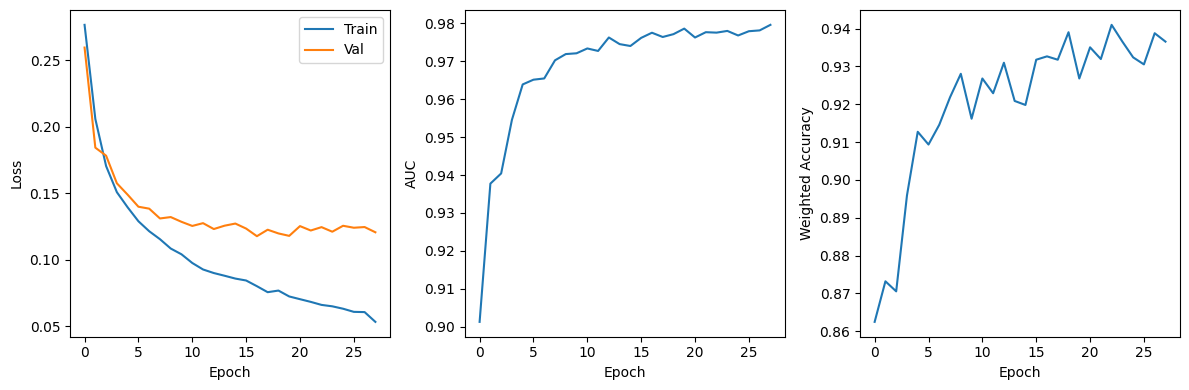

In [ ]:
best_model, history = train_model(model, train_loader, val_loader,
                                  epochs=config['epochs'],
                                  lr=config['lr'],
                                  weight=config['weight'],
                                  patience=5)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history['val_auc'])
plt.xlabel('Epoch')
plt.ylabel('AUC')

plt.subplot(1,3,3)
plt.plot(history['val_wa'])
plt.xlabel('Epoch')
plt.ylabel('Weighted Accuracy')

plt.tight_layout()
plt.show()

In [ ]:
# comments

In [ ]:
test_dataset = CocrystalDataset(
    df_test,
    augment=False,
    global_features=use_global,
    fingerprint=use_fp,
    global_scaler=global_scaler,
    cache_graphs=True
)

print(f"Test dataset size: {len(test_dataset)}, original test size: {len(df_test)}")
if len(test_dataset) != len(df_test):
    print("Warning: Some test samples were dropped. Check your data.")

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_cocrystal
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model.to(device)
best_model.eval()

all_preds = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting on test"):
        mol1 = batch['mol1'].to(device)
        mol2 = batch['mol2'].to(device)

        kwargs = {}
        if 'global1' in batch:
            kwargs['global1'] = batch['global1'].to(device)
            kwargs['global2'] = batch['global2'].to(device)
        if 'fp1' in batch:
            kwargs['fp1'] = batch['fp1'].to(device)
            kwargs['fp2'] = batch['fp2'].to(device)

        out = best_model(mol1, mol2, **kwargs).squeeze()
        preds = (out > 0.5).cpu().numpy().astype(int)
        all_preds.extend(preds)

if len(all_preds) != len(df_test):
    print(f"Warning: Number of predictions ({len(all_preds)}) != test size ({len(df_test)}).")

submission = pd.DataFrame({
    'id': df_test['id'],
    'result': all_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")
print(submission.head())